<a href="https://colab.research.google.com/github/Prajwal-13-dev/precision-marketing-poc/blob/main/precision_marketing_poc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier, plot_importance
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import warnings

In [61]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
%cd "/content/drive/MyDrive/precision-marketing-poc"

/content/drive/MyDrive/precision-marketing-poc


In [63]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")


OK  /content/drive/MyDrive/precision-marketing-poc/telecom/Client.csv
OK  /content/drive/MyDrive/precision-marketing-poc/telecom/Record.csv


In [64]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [65]:

df = pd.merge(client, record, on='Customer_ID', how='inner')
print(f"Merged Dataset Shape: {df.shape}")

Merged Dataset Shape: (100000, 100)


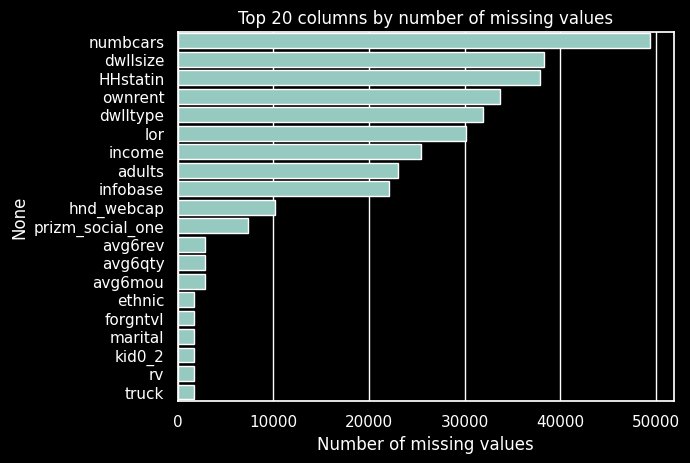

In [66]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


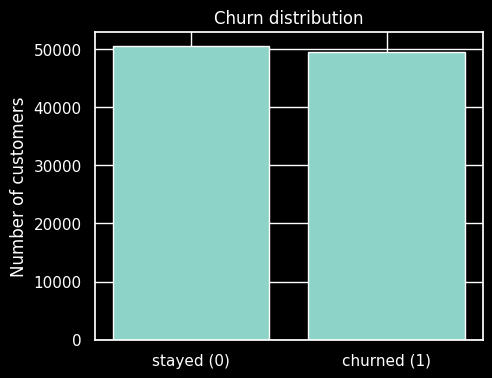

In [67]:
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

Creating the Marketing Personas ('Cluster' column)...


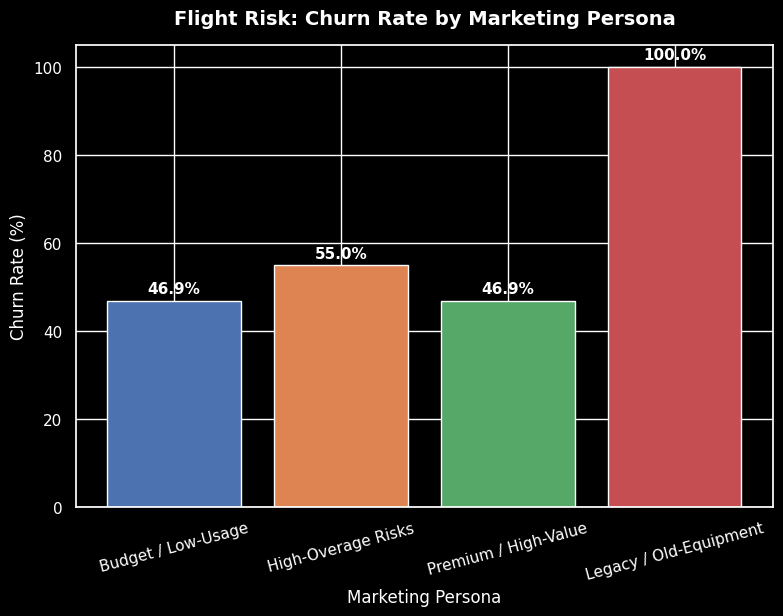

In [68]:
if 'Cluster' not in df.columns:
    print("Creating the Marketing Personas ('Cluster' column)...")
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.impute import SimpleImputer

    features = ['avgrev', 'avgmou', 'totmrc_Mean', 'ovrmou_Mean', 'roam_Mean', 'eqpdays']
    X = df[features]
    X_imputed = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=X.columns)
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_imputed), columns=X.columns)

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df['Cluster'] = kmeans.fit_predict(X_scaled)

#Calculate the percentage of churn within each specific persona
persona_churn = df.groupby('Cluster')['churn'].mean() * 100

# Set up the visualization
plt.figure(figsize=(9, 6))
bars = plt.bar(persona_churn.index, persona_churn.values,
               color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

plt.title('Flight Risk: Churn Rate by Marketing Persona', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Marketing Persona', fontsize=12)

# Use the names we defined earlier instead of 0, 1, 2, 3
labels = ["Budget / Low-Usage", "High-Overage Risks", "Premium / High-Value", "Legacy / Old-Equipment"]
plt.xticks(ticks=[0, 1, 2, 3], labels=labels, rotation=15)

# Add the exact percentages on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.show()

Generating Pairwise View (this may take a few seconds)...


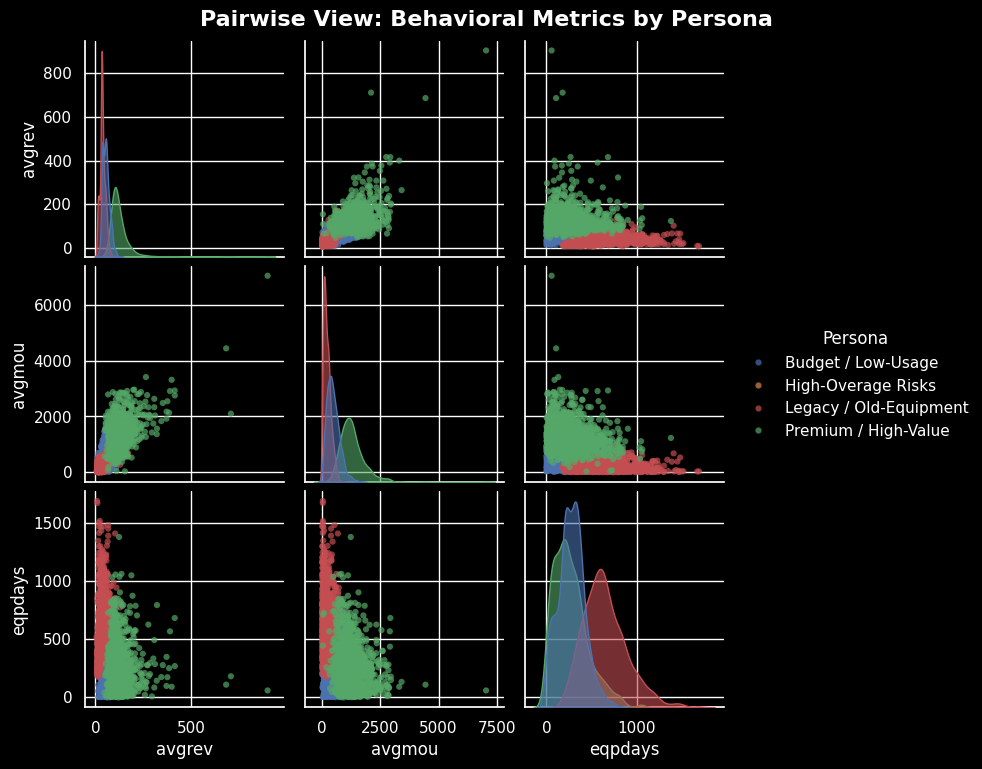

In [69]:
#Map the cluster numbers to the actual persona names
persona_mapping = {
    0: "Premium / High-Value",
    1: "Legacy / Old-Equipment",
    2: "Budget / Low-Usage",
    3: "High-Overage Risks"
}
if 'Persona' not in df.columns:
    df['Persona'] = df['Cluster'].map(persona_mapping)

pairwise_features = ['avgrev', 'avgmou', 'eqpdays', 'Persona']

sample_list = []
for _, group in df[pairwise_features].groupby('Persona'):
    sample_list.append(group.sample(min(len(group), 1250)))
sample_df = pd.concat(sample_list)

#Explicit Color Mapping
custom_palette = {
    "Budget / Low-Usage": "#4C72B0",
    "High-Overage Risks": "#DD8452",
    "Premium / High-Value": "#55A868",
    "Legacy / Old-Equipment": "#C44E52"
}

#Generate the Pairwise plot
print("Generating Pairwise View (this may take a few seconds)...")
pair_plot = sns.pairplot(
    sample_df,
    hue='Persona',
    palette=custom_palette,
    plot_kws={'alpha': 0.7, 's': 20, 'edgecolor': 'none'},
    diag_kws={'fill': True, 'alpha': 0.6}
)

pair_plot.fig.suptitle('Pairwise View: Behavioral Metrics by Persona', y=1.02, fontsize=16, fontweight='bold', color='white')
plt.show()

In [70]:


features = ['avgrev', 'avgmou', 'totmrc_Mean', 'ovrmou_Mean', 'roam_Mean', 'eqpdays']
TARGET   = 'churn'

# Keep only rows where churn label exists
df_model = df[features + [TARGET]].copy()
df_model = df_model.dropna(subset=[TARGET])
df_model[TARGET] = df_model[TARGET].astype(int)

print(f"Dataset size after dropping missing churn labels: {df_model.shape}")
print(f"Overall churn rate: {df_model[TARGET].mean()*100:.1f}%")

# Impute features
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(df_model[features]),
    columns=features,
    index=df_model.index
)
y_churn = df_model[TARGET]





Dataset size after dropping missing churn labels: (100000, 7)
Overall churn rate: 49.6%


In [71]:
!pip install xgboost

K-Means pool      : 60,000 records
XGBoost train set : 20,000 records
Final holdout     : 20,000 records


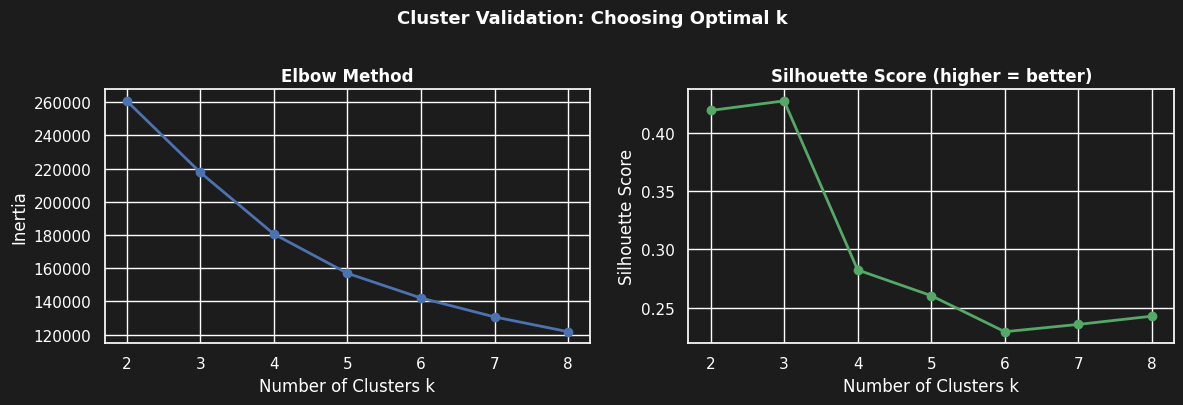

Saved: cluster_validation.png

Final K-Means Silhouette Score (k=4): 0.2794
  → Score > 0.5 = strong clusters | 0.3-0.5 = reasonable | <0.3 = weak

Cluster Centroids (original scale):
   avgrev   avgmou  totmrc_Mean  ovrmou_Mean  roam_Mean  eqpdays
0   37.92   201.12        31.40        15.82       0.62   641.32
1   64.63   525.85        53.36        37.65       1.24   294.60
2  136.74  1313.88        84.33       205.75       4.55   284.85
3  169.98   681.07        30.00        82.25    3685.20    54.00

Auto-assigned Persona Labels:
  Cluster 0 → Legacy / Old-Equipment
  Cluster 1 → Budget / Low-Usage
  Cluster 2 → High-Overage Risks
  Cluster 3 → Premium / High-Value

Persona distribution in XGBoost training set:
  Budget / Low-Usage             12,306 (61.5%)
  Legacy / Old-Equipment          5,756 (28.8%)
  High-Overage Risks              1,938 (9.7%)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=4, ...)

In [72]:
#  K-Means trains on the FIRST 60% of records
#  XGBoost trains on the NEXT 20% (using K-Means labels)
#  Final evaluation on the LAST 20%

n = len(X_imputed)
cut1 = int(n * 0.60)
cut2 = int(n * 0.80)

X_kmeans_pool = X_imputed.iloc[:cut1]
X_xgb_train   = X_imputed.iloc[cut1:cut2]
X_holdout      = X_imputed.iloc[cut2:]
y_holdout      = y_churn.iloc[cut2:]

print(f"K-Means pool      : {len(X_kmeans_pool):,} records")
print(f"XGBoost train set : {len(X_xgb_train):,} records")
print(f"Final holdout     : {len(X_holdout):,} records")

# Scale AFTER splitting
scaler = StandardScaler()
X_kmeans_scaled = pd.DataFrame(
    scaler.fit_transform(X_kmeans_pool), columns=features)
X_xgb_scaled    = pd.DataFrame(
    scaler.transform(X_xgb_train), columns=features)
X_holdout_scaled = pd.DataFrame(
    scaler.transform(X_holdout), columns=features)

# Elbow + Silhouette to validate k=4
inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_kmeans_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_kmeans_scaled, labels, sample_size=5000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#1c1c1c')
for ax in axes:
    ax.set_facecolor('#1c1c1c')

axes[0].plot(list(k_range), inertias, 'o-', color='#4C72B0', linewidth=2)
axes[0].set_title('Elbow Method', color='white', fontweight='bold')
axes[0].set_xlabel('Number of Clusters k', color='white')
axes[0].set_ylabel('Inertia', color='white')
axes[0].tick_params(colors='white')

axes[1].plot(list(k_range), silhouettes, 'o-', color='#55A868', linewidth=2)
axes[1].set_title('Silhouette Score (higher = better)', color='white', fontweight='bold')
axes[1].set_xlabel('Number of Clusters k', color='white')
axes[1].set_ylabel('Silhouette Score', color='white')
axes[1].tick_params(colors='white')

plt.suptitle('Cluster Validation: Choosing Optimal k', color='white',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Saved: cluster_validation.png")

# Fit final K-Means with k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_final.fit(X_kmeans_scaled)

sil = silhouette_score(X_kmeans_scaled,
                       kmeans_final.labels_, sample_size=5000)
print(f"\nFinal K-Means Silhouette Score (k=4): {sil:.4f}")
print("  → Score > 0.5 = strong clusters | 0.3-0.5 = reasonable | <0.3 = weak")


centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=features
)
print("\nCluster Centroids (original scale):")
print(centroids.round(2).to_string())


persona_map = {}
for i, row in centroids.iterrows():
    if row['eqpdays'] == centroids['eqpdays'].max():
        persona_map[i] = 'Legacy / Old-Equipment'
    elif row['avgrev'] == centroids['avgrev'].max():
        persona_map[i] = 'Premium / High-Value'
    elif row['ovrmou_Mean'] == centroids['ovrmou_Mean'].max():
        persona_map[i] = 'High-Overage Risks'
    else:
        persona_map[i] = 'Budget / Low-Usage'

print("\nAuto-assigned Persona Labels:")
for k, v in persona_map.items():
    print(f"  Cluster {k} → {v}")

xgb_labels = kmeans_final.predict(X_xgb_scaled)

# Cluster size check — flag if any cluster is < 2% of the XGB training set
label_counts = pd.Series(xgb_labels).value_counts()
print("\nPersona distribution in XGBoost training set:")
for cluster_id, count in label_counts.items():
    pct = count / len(xgb_labels) * 100
    flag = " ⚠️  TINY CLUSTER — interpret with caution" if pct < 2 else ""
    print(f"  {persona_map[cluster_id]:<30} {count:>6,} ({pct:.1f}%){flag}")


# Further split XGB set for internal validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_xgb_scaled, xgb_labels, test_size=0.25, random_state=42,
    stratify=xgb_labels
)

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    verbosity=0
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)


Honest Holdout Accuracy: 97.27%
(Anything 75–90% is strong; 98%+ on this setup would be suspicious)

Detailed Persona Report:
                        precision    recall  f1-score   support

Legacy / Old-Equipment       0.99      0.92      0.95      4256
    Budget / Low-Usage       0.97      0.99      0.98     13281
    High-Overage Risks       0.98      0.96      0.97      2463
  Premium / High-Value       0.00      0.00      0.00         0

              accuracy                           0.97     20000
             macro avg       0.73      0.72      0.73     20000
          weighted avg       0.97      0.97      0.97     20000



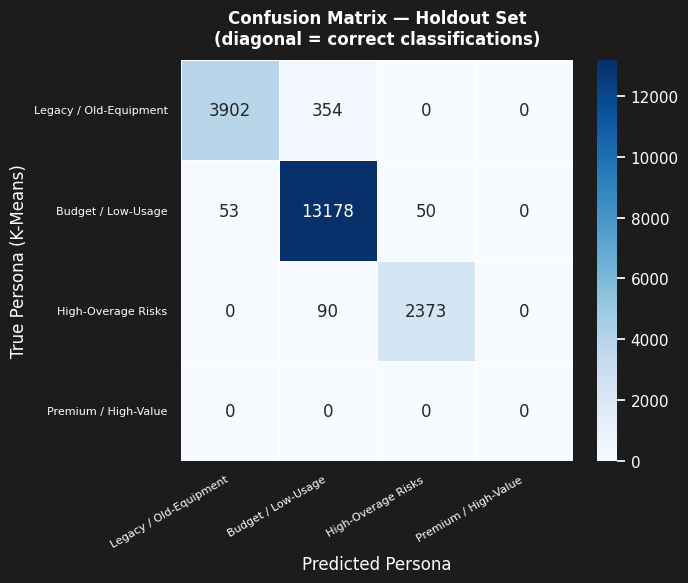


Churn Rate by Predicted Persona (on real churn labels):
                        n_customers  churn_rate_pct
persona_name                                       
Legacy / Old-Equipment         3955            49.3
High-Overage Risks             2423            42.3
Budget / Low-Usage            13622            39.3


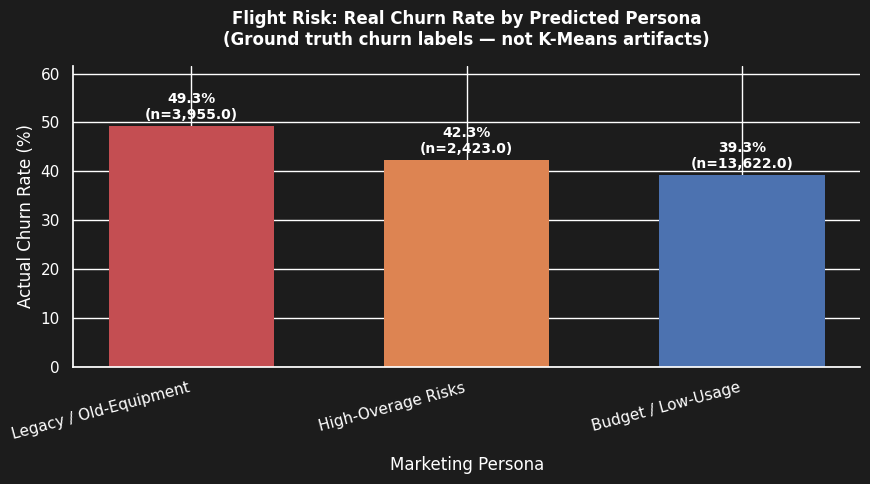

In [73]:

ACCENT = ['#C44E52', '#DD8452', '#4C72B0', '#55A868']
holdout_labels = kmeans_final.predict(X_holdout_scaled)
y_pred         = xgb_model.predict(X_holdout_scaled)

accuracy = accuracy_score(holdout_labels, y_pred)
print(f"\nHonest Holdout Accuracy: {accuracy * 100:.2f}%")

target_names = [persona_map[i] for i in range(4)]
print("\nDetailed Persona Report:")
print(classification_report(
    holdout_labels, y_pred,
    labels=[0, 1, 2, 3],
    target_names=target_names,
    zero_division=0
))

# ── Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6), facecolor='#1c1c1c')
ax.set_facecolor('#1c1c1c')
cm = confusion_matrix(holdout_labels, y_pred, labels=[0, 1, 2, 3])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax,
            linewidths=0.5)
ax.set_title('Confusion Matrix — Holdout Set\n(diagonal = correct classifications)',
             color='white', fontweight='bold', pad=12)
ax.set_xlabel('Predicted Persona', color='white')
ax.set_ylabel('True Persona (K-Means)', color='white')
plt.xticks(rotation=30, ha='right', color='white', fontsize=8)
plt.yticks(rotation=0, color='white', fontsize=8)
plt.tight_layout()
plt.show()

# CHURN VALIDATION


# Tag holdout rows with their predicted persona
holdout_df = X_holdout.copy()
holdout_df['predicted_persona_id'] = y_pred
holdout_df['churn'] = y_holdout.values
holdout_df['persona_name'] = holdout_df['predicted_persona_id'].map(persona_map)

churn_by_persona = (
    holdout_df.groupby('persona_name')['churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n_customers'})
    .sort_values('churn_rate', ascending=False)
)
churn_by_persona['churn_rate_pct'] = (churn_by_persona['churn_rate'] * 100).round(1)

print("\nChurn Rate by Predicted Persona (on real churn labels):")
print(churn_by_persona[['n_customers', 'churn_rate_pct']].to_string())

# Flight Risk Chart
fig, ax = plt.subplots(figsize=(9, 5), facecolor='#1c1c1c')
ax.set_facecolor('#1c1c1c')

bars = ax.bar(
    churn_by_persona.index,
    churn_by_persona['churn_rate_pct'],
    color=ACCENT[:len(churn_by_persona)],
    edgecolor='none',
    width=0.6
)
for bar, (_, row) in zip(bars, churn_by_persona.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{row['churn_rate_pct']}%\n(n={row['n_customers']:,})",
            ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

ax.set_title('Flight Risk: Real Churn Rate by Predicted Persona\n'
             '(Ground truth churn labels — not K-Means artifacts)',
             color='white', fontweight='bold', pad=15)
ax.set_xlabel('Marketing Persona', color='white', labelpad=10)
ax.set_ylabel('Actual Churn Rate (%)', color='white')
ax.tick_params(colors='white')
ax.set_ylim(0, churn_by_persona['churn_rate_pct'].max() * 1.25)
plt.xticks(rotation=15, ha='right')
sns.despine()
plt.tight_layout()
plt.show()




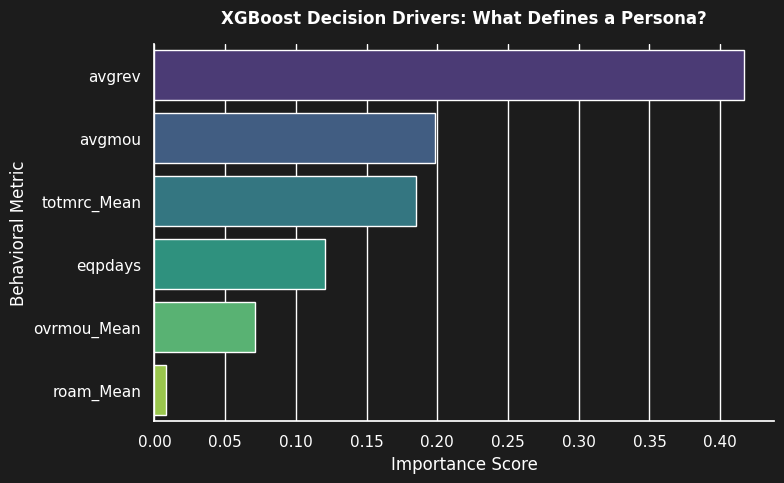

Saved: feature_importance.png

STEP 9: Production Scorer Example

New Subscriber Classification:
  Persona     : Legacy / Old-Equipment
  Confidence  : 93.9%
  All Probas  : {'Legacy / Old-Equipment': '93.9%', 'Budget / Low-Usage': '6.0%', 'High-Overage Risks': '0.0%'}


In [74]:

# STEP 8 ── FEATURE IMPORTANCE

importances = xgb_model.feature_importances_

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#1c1c1c')
ax.set_facecolor('#1c1c1c')
order_idx = importances.argsort()[::-1]
sns.barplot(x=importances[order_idx],
            y=np.array(features)[order_idx],
            palette='viridis', ax=ax)
ax.set_title('XGBoost Decision Drivers: What Defines a Persona?',
             color='white', fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', color='white')
ax.set_ylabel('Behavioral Metric', color='white')
ax.tick_params(colors='white')
sns.despine()
plt.tight_layout()
plt.show()
print("Saved: feature_importance.png")


#  PRODUCTION SCORER

print("Production Scorer Example")


def classify_new_subscriber(raw_features: dict) -> dict:
    """
    Input : dict with keys matching `features` list
    Output: persona name + churn risk tier
    """
    X_new = pd.DataFrame([raw_features])[features]
    X_new_imputed = pd.DataFrame(imputer.transform(X_new), columns=features)
    X_new_scaled  = pd.DataFrame(scaler.transform(X_new_imputed), columns=features)
    persona_id    = xgb_model.predict(X_new_scaled)[0]
    proba         = xgb_model.predict_proba(X_new_scaled)[0]
    return {
        'persona'    : persona_map[persona_id],
        'confidence' : f"{proba[persona_id]*100:.1f}%",
        'all_probas' : {persona_map[i]: f"{p*100:.1f}%"
                        for i, p in enumerate(proba)}
    }

# Example new subscriber
new_sub = {
    'avgrev'     : 45.0,
    'avgmou'     : 200.0,
    'totmrc_Mean': 40.0,
    'ovrmou_Mean': 5.0,
    'roam_Mean'  : 0.0,
    'eqpdays'    : 900.0   # old equipment → expect Legacy persona
}
result = classify_new_subscriber(new_sub)
print(f"\nNew Subscriber Classification:")
print(f"  Persona     : {result['persona']}")
print(f"  Confidence  : {result['confidence']}")
print(f"  All Probas  : {result['all_probas']}")
